In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [20]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 8.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 3.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

testset = CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [3]:
def train(model, trainloader, optimizer, criterion, epochs=1):
    model.train()
    for epoch in range(epochs):
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

def evaluate(model, testloader, criterion):
    model.eval()
    correct, total, loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return loss / total, accuracy


In [24]:
import flwr as fl
from collections import OrderedDict
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

def get_parameters(model):
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

class FlowerClient(fl.client.NumPyClient):
    def __init__(self, model, trainloader, testloader):
        self.model = model
        self.trainloader = trainloader
        self.testloader = testloader
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        train(self.model, self.trainloader, self.optimizer, self.criterion, epochs=1)
        return get_parameters(self.model), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        loss, accuracy = evaluate(self.model, self.testloader, self.criterion)
        return float(loss), len(self.testloader.dataset), {"accuracy": float(accuracy)}

def client_fn(cid: str):
    print(f"Creating client {cid}")
    model = SimpleCNN().to(DEVICE)
    return FlowerClient(model, trainloader, testloader).to_client()

def weighted_average(metrics):
    accuracies = [m["accuracy"] for _, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    weighted_avg = np.average(accuracies, weights=examples)
    return {"accuracy": weighted_avg}

strategy = fl.server.strategy.FedAvg(evaluate_metrics_aggregation_fn=weighted_average)

print("Starting simulation...")
history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=5,
    config=fl.server.ServerConfig(num_rounds=10),  # Reduced number of rounds for demo
    strategy=strategy,
)
print("Simulation ended.")


INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout


Starting simulation...


2024-06-09 01:57:18,526	INFO worker.py:1621 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 18987178394.0, 'object_store_memory': 2147483648.0, 'node:127.0.0.1': 1.0, 'node:__internal_head__': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 12 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)


(ClientAppActor pid=19780) Creating client 0
(ClientAppActor pid=19780) Creating client 1


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)


...

(ClientAppActor pid=19780) Creating client 4 [repeated 5x across cluster]


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)


(ClientAppActor pid=19779) Creating client 4 [repeated 5x across cluster]


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 rounds in 451.47s
INFO :      History (loss, distributed):
INFO :      	('\tround 1: 0.04175062086582184\n'
INFO :      	 '\tround 2: 0.025479928627610206\n'
INFO :      	 '\tround 3: 0.022643455636501313\n'
INFO :      	 '\tround 4: 0.022247534719109535\n'
INFO :      	 '\tround 5: 0.023457210645079614\n'
INFO :      	 '\tround 6: 0.02670132877230644\n'
INFO :      	 '\tround 7: 0.031128480780124663\n'
INFO :      	 '\tround 8: 0.03629953286647797\n'
INFO :      	 '\tround 9: 0.04198345837593079\n'
INFO :      	 '\tround 10: 0.045308899736404416\n')History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.5866),
INFO :      	              (2, 0.7171999999999998),
INFO :      	              (3, 0.753),
INFO :      	              (4, 0.7614),
INFO :      	              (5, 0.7602),
INFO :      	              (6, 0.7534),
INFO :      	         

Simulation ended.


In [25]:
print(history)


History (loss, distributed):
('\tround 1: 0.04175062086582184\n'
 '\tround 2: 0.025479928627610206\n'
 '\tround 3: 0.022643455636501313\n'
 '\tround 4: 0.022247534719109535\n'
 '\tround 5: 0.023457210645079614\n'
 '\tround 6: 0.02670132877230644\n'
 '\tround 7: 0.031128480780124663\n'
 '\tround 8: 0.03629953286647797\n'
 '\tround 9: 0.04198345837593079\n'
 '\tround 10: 0.045308899736404416\n')History (metrics, distributed, evaluate):
{'accuracy': [(1, 0.5866),
              (2, 0.7171999999999998),
              (3, 0.753),
              (4, 0.7614),
              (5, 0.7602),
              (6, 0.7534),
              (7, 0.7538),
              (8, 0.7511),
              (9, 0.7476),
              (10, 0.7423999999999998)]}


In [6]:
def train_centralized(trainloader, testloader):
    model = SimpleCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 10  # Reduced number of epochs for demo
    print("started ... ")

    train_loss, train_acc = [], []  # Initialize as empty lists

    for epoch in range(num_epochs):
        print(f"epoch {epoch}") 
        train(model, trainloader, optimizer, criterion)
        loss, accuracy = evaluate(model, testloader, criterion)
        train_loss.append(loss)
        train_acc.append(accuracy)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

    return model, train_loss, train_acc

centralized_model, centralized_loss, centralized_accuracy = train_centralized(trainloader, testloader)


started ... 
epoch 0
Epoch 1/10, Loss: 0.0314, Accuracy: 0.6458
epoch 1
Epoch 2/10, Loss: 0.0279, Accuracy: 0.6935
epoch 2
Epoch 3/10, Loss: 0.0258, Accuracy: 0.7156
epoch 3
Epoch 4/10, Loss: 0.0261, Accuracy: 0.7208
epoch 4
Epoch 5/10, Loss: 0.0252, Accuracy: 0.7309
epoch 5
Epoch 6/10, Loss: 0.0281, Accuracy: 0.7177
epoch 6
Epoch 7/10, Loss: 0.0308, Accuracy: 0.7109
epoch 7
Epoch 8/10, Loss: 0.0341, Accuracy: 0.7155
epoch 8
Epoch 9/10, Loss: 0.0382, Accuracy: 0.7123
epoch 9
Epoch 10/10, Loss: 0.0432, Accuracy: 0.7194


In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, cohen_kappa_score
import torch.nn.functional as F

def compute_metrics(model, dataloader):
    model.eval()
    all_labels = []
    all_probabilities = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='macro')
    roc = roc_auc_score(all_labels, all_probabilities, multi_class='ovr')
    kappa = cohen_kappa_score(all_labels, all_predictions)
    return accuracy, f1, roc, kappa

centralized_metrics = compute_metrics(centralized_model, testloader)
print(f"Centralized Metrics: {centralized_metrics}")


Centralized Metrics: (0.7194, 0.7191409522862544, 0.9561053611111111, 0.6882222222222221)


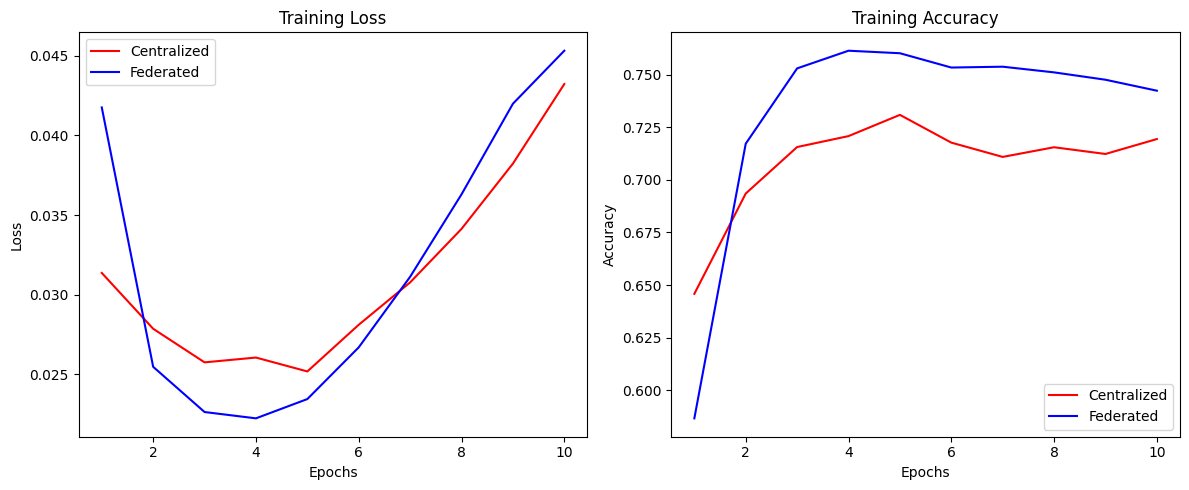

In [26]:
import matplotlib.pyplot as plt

def plot_metrics(centralized_loss, federated_loss, centralized_acc, federated_acc):
    epochs = range(1, len(centralized_loss) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, centralized_loss, 'r', label='Centralized')
    plt.plot(epochs, federated_loss, 'b', label='Federated')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, centralized_acc, 'r', label='Centralized')
    plt.plot(epochs, federated_acc, 'b', label='Federated')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

federated_loss = [0.04175062086582184, 0.025479928627610206, 0.022643455636501313, 0.022247534719109535, 0.023457210645079614, 0.02670132877230644, 0.031128480780124663, 0.03629953286647797, 0.04198345837593079, 0.045308899736404416]
federated_acc = [0.5866, 0.71719, 0.753, 0.7614, 0.7602, 0.7534, 0.7538, 0.7511, 0.7476, 0.74239]

plot_metrics(centralized_loss, federated_loss, centralized_accuracy, federated_acc)


In [27]:
!pip install fedn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 5.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 12.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 6.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.5/485.5 kB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 6.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.64.1
    Uninstalling grpcio-1.64.1:
      Successfully uninstalled grpcio-1.64.1


In [35]:
import fedn

# Define the FedN client
class FedNClient(fedn.Client):
    def __init__(self, client_id, model, trainloader, testloader):
        super().__init__(client_id)
        self.model = model
        self.trainloader = trainloader
        self.testloader = testloader
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)

    def get_weights(self):
        print(f"Client {self.client_id}: Getting weights")
        return {k: v.cpu().numpy() for k, v in self.model.state_dict().items()}

    def set_weights(self, weights):
        print(f"Client {self.client_id}: Setting weights")
        self.model.load_state_dict({k: torch.tensor(v) for k, v in weights.items()})

    def train(self, task, context):
        print(f"Client {self.client_id}: Training")
        self.set_weights(context['weights'])
        train(self.model, self.trainloader, self.optimizer, self.criterion, epochs=1)
        updated_weights = self.get_weights()
        print(f"Client {self.client_id}: Training complete")
        return TrainingResult(weights=updated_weights)

    def evaluate(self, task, context):
        print(f"Client {self.client_id}: Evaluating")
        self.set_weights(context['weights'])
        loss, accuracy = evaluate(self.model, self.testloader, self.criterion)
        print(f"Client {self.client_id}: Evaluation complete - Loss: {loss}, Accuracy: {accuracy}")
        return TrainingResult(loss=loss, accuracy=accuracy)

# Define the FedN aggregator
class FedNAggregator(fedn.aggregator.Aggregator):
    def __init__(self):
        super().__init__()
        self.global_model = SimpleCNN().to(DEVICE)

    def aggregate(self, context, task, training_results):
        print("Aggregating updates")
        aggregated_weights = {k: np.mean([result['weights'][k] for result in training_results], axis=0) for k in training_results[0]['weights'].keys()}
        self.global_model.load_state_dict({k: torch.tensor(v) for k, v in aggregated_weights.items()})
        print("Aggregation complete")
        return TrainingResult(weights=aggregated_weights)

# Initialize and run the FedN aggregator and clients
def run_fedn_aggregator():
    aggregator = FedNAggregator()
    fedn.run_aggregator(aggregator)

def run_fedn_client(client_id):
    model = SimpleCNN().to(DEVICE)
    trainloader = DataLoader(CIFAR10(root='./data', train=True, download=True, transform=transform), batch_size=BATCH_SIZE, shuffle=True)
    testloader = DataLoader(CIFAR10(root='./data', train=False, download=True, transform=transform), batch_size=BATCH_SIZE, shuffle=False)
    client = FedNClient(client_id, model, trainloader, testloader)
    fedn.run_client(client)

# Run the aggregator and clients (in separate scripts or processes)
import threading

aggregator_thread = threading.Thread(target=run_fedn_aggregator)
aggregator_thread.start()

client_threads = []
for i in range(5):
    client_thread = threading.Thread(target=run_fedn_client, args=(i,))
    client_threads.append(client_thread)
    client_thread.start()

for client_thread in client_threads:
    client_thread.join()

AttributeError: module 'fedn' has no attribute 'Client'